In [18]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
query = """
SELECT *
FROM features.customer_features
"""

customer_df = pd.read_sql(query, engine)

customer_df.shape

(206209, 14)

In [21]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206209 entries, 0 to 206208
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  206209 non-null  int64  
 1   total_orders             206209 non-null  int64  
 2   total_items              206209 non-null  int64  
 3   unique_products          206209 non-null  int64  
 4   avg_basket_size          206209 non-null  float64
 5   avg_days_between_orders  206209 non-null  float64
 6   std_days_between_orders  206209 non-null  float64
 7   customer_tenure          206209 non-null  int64  
 8   reorder_rate             206209 non-null  float64
 9   total_reorders           206209 non-null  int64  
 10  unique_departments       206209 non-null  int64  
 11  unique_aisles            206209 non-null  int64  
 12  favorite_hour            206209 non-null  int64  
 13  favorite_day             206209 non-null  int64  
dtypes: f

In [22]:
customer_df.head()

,user_id,total_orders,total_items,unique_products,avg_basket_size,avg_days_between_orders,std_days_between_orders,customer_tenure,reorder_rate,total_reorders,unique_departments,unique_aisles,favorite_hour,favorite_day
0,18,6,39,29,6.500000,6.466667,2.991175,6,0.256410,10,9,20,16,2
1,37,23,188,104,8.173913,12.687500,7.682936,23,0.446809,84,15,34,16,5
2,38,12,195,88,16.250000,22.878453,7.206990,12,0.548718,107,14,40,10,6
3,47,5,26,21,5.200000,9.750000,4.165965,5,0.192308,5,13,20,10,2
4,50,67,453,89,6.761194,5.691275,3.050912,67,0.803532,364,11,38,10,1


In [23]:
customer_df.isnull().sum()

user_id                    0
total_orders               0
total_items                0
unique_products            0
avg_basket_size            0
avg_days_between_orders    0
std_days_between_orders    0
customer_tenure            0
reorder_rate               0
total_reorders             0
unique_departments         0
unique_aisles              0
favorite_hour              0
favorite_day               0
dtype: int64

In [24]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,206209.0,103105.000000,59527.555167,1.0,51553.000000,103105.000000,154657.000000,206209.000000
total_orders,206209.0,15.590367,16.654774,3.0,5.000000,9.000000,19.000000,99.000000
total_items,206209.0,157.289396,204.208233,3.0,39.000000,83.000000,188.000000,3725.000000
unique_products,206209.0,64.536238,56.592339,1.0,25.000000,48.000000,86.000000,726.000000
avg_basket_size,206209.0,9.951586,5.863570,1.0,5.740741,8.933333,13.000000,70.250000
avg_days_between_orders,206209.0,15.469670,7.207436,0.0,9.553797,14.692308,20.724409,30.000000
std_days_between_orders,206209.0,6.616467,3.268528,0.0,4.231001,7.033376,9.037772,21.213203
customer_tenure,206209.0,15.590367,16.654774,3.0,5.000000,9.000000,19.000000,99.000000
reorder_rate,206209.0,0.432249,0.212144,0.0,0.267857,0.428571,0.595745,0.989529
total_reorders,206209.0,92.753158,158.400413,0.0,10.000000,33.000000,101.000000,3275.000000


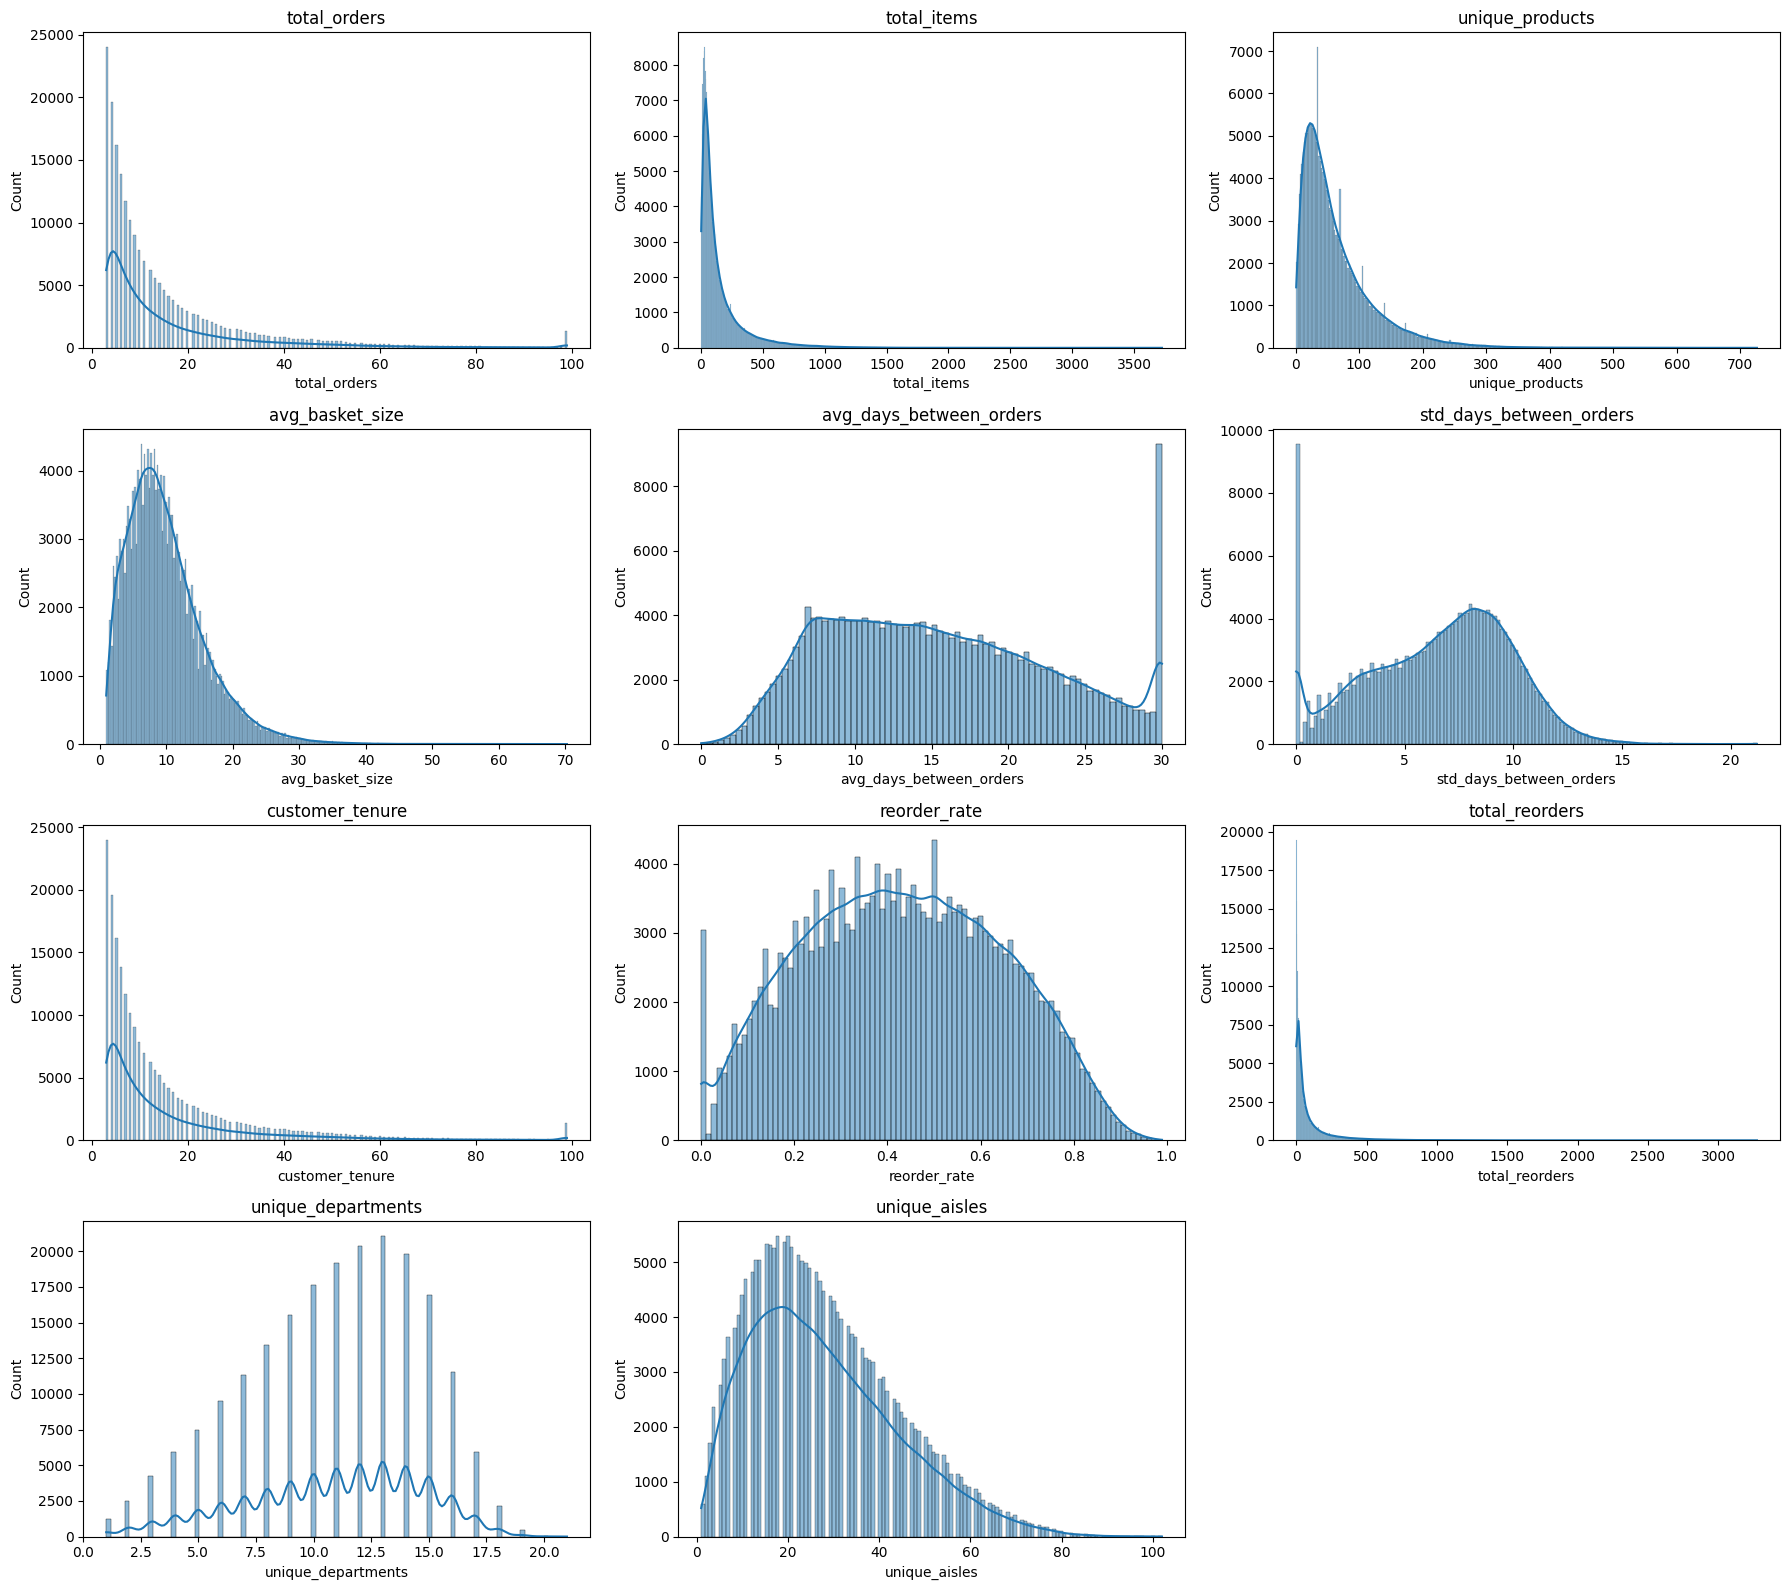

In [25]:
# Exclude ID column
continuous_cols = [
    'total_orders',
    'total_items',
    'unique_products',
    'avg_basket_size',
    'avg_days_between_orders',
    'std_days_between_orders',
    'customer_tenure',
    'reorder_rate',
    'total_reorders',
    'unique_departments',
    'unique_aisles'
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18, 16)
)

axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(
        data=customer_df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove unused subplot
for j in range(len(continuous_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Customer Feature Distribution Analysis

The distribution plots provide important insights into customer purchasing behavior within the Instacart dataset. Most customer activity metrics exhibit strong right-skewed distributions, indicating that a small number of highly active customers contribute disproportionately to overall platform activity.

### 1. Total Orders

The `total_orders` feature is highly right-skewed. Most customers have placed fewer than 20 orders, while a small group of highly engaged customers have placed more than 50 orders. This suggests the presence of a loyal customer segment that contributes significantly to platform activity.

**Insight:** Customer purchasing frequency varies substantially, making this feature useful for identifying casual and highly engaged shoppers.

---

### 2. Total Items Purchased

The `total_items` distribution is extremely right-skewed. While most customers purchase relatively few items, a small number purchase thousands of products.

**Insight:** The dataset contains power users or high-volume shoppers whose purchasing behavior differs significantly from the average customer.

---

### 3. Unique Products Purchased

The `unique_products` feature also shows a strong right-skewed distribution. Most customers repeatedly purchase a limited set of products, while a smaller group explores a much wider range of items.

**Insight:** This feature captures customer exploration behavior and can distinguish habitual buyers from exploratory shoppers.

---

### 4. Average Basket Size

The distribution of `avg_basket_size` is moderately right-skewed, with most customers purchasing between 5 and 15 items per order.

**Insight:** Typical customer orders are relatively small, while a minority of customers place significantly larger orders, indicating bulk purchasing behavior.

---

### 5. Average Days Between Orders

The `avg_days_between_orders` distribution reveals a noticeable concentration around 30 days.

**Insight:** Many customers exhibit monthly purchasing patterns, suggesting recurring shopping cycles and regular replenishment behavior.

---

### 6. Standard Deviation of Days Between Orders

The `std_days_between_orders` feature displays an approximately bell-shaped distribution.

**Insight:** This metric captures customer consistency. Lower values indicate predictable purchasing behavior, whereas higher values suggest irregular shopping patterns.

---

### 7. Reorder Rate

The `reorder_rate` distribution is relatively balanced and centered around 0.4–0.6.

**Insight:** Customers generally reorder a substantial proportion of previously purchased products, indicating moderate to strong customer loyalty across the platform.

---

### 8. Total Reorders

The `total_reorders` feature is highly right-skewed, similar to `total_items`.

**Insight:** A small subset of customers generates a large number of repeat purchases, highlighting the importance of loyal customers in overall sales volume.

---

### 9. Unique Departments Purchased

Most customers purchase products from approximately 10–15 departments.

**Insight:** Customers tend to shop across multiple product categories rather than focusing on a single department, indicating diverse purchasing behavior.

---

### 10. Unique Aisles Purchased

The `unique_aisles` feature shows a moderately right-skewed distribution with most customers purchasing from 20–40 aisles.

**Insight:** Customers typically explore a broad range of product categories, providing opportunities for cross-selling and recommendation strategies.

---

## Overall Findings

### Key Customer Behaviors

- Most customer activity metrics exhibit strong right-skewness, indicating the presence of a small number of highly active customers.
- Customers generally display moderate loyalty, as evidenced by reorder rates centered around 40–60%.
- Shopping behavior is often cyclical, with many customers placing orders approximately once per month.
- Product and category diversity vary considerably across customers, suggesting distinct shopping preferences and behaviors.
- The dataset contains both habitual shoppers with repetitive purchasing patterns and exploratory shoppers who purchase a wide variety of products.

### Business Implications

- High-value customers contribute disproportionately to platform activity and should be prioritized for retention efforts.
- Reorder behavior serves as a strong indicator of customer loyalty.
- Monthly ordering patterns can inform inventory planning and targeted marketing campaigns.
- Product diversity metrics can support customer segmentation and personalized recommendation systems.
- Category exploration patterns provide opportunities for cross-selling and customer engagement initiatives.

In [26]:
eda_summary = pd.DataFrame({
    "dtype": customer_df.dtypes,
    "missing": customer_df.isnull().sum(),
    "unique": customer_df.nunique(),
    "skewness": customer_df.skew(numeric_only=True),
    "kurtosis": customer_df.kurtosis(numeric_only=True)
})

eda_summary

,dtype,missing,unique,skewness,kurtosis
user_id,int64,0,206209,2.354206e-17,-1.200000
total_orders,int64,0,97,2.400456e+00,6.755164
total_items,int64,0,1708,3.179127e+00,15.351197
unique_products,int64,0,493,1.921483e+00,5.406543
avg_basket_size,float64,0,18929,1.230259e+00,2.630593
avg_days_between_orders,float64,0,99570,3.289663e-01,-0.815473
std_days_between_orders,float64,0,175154,-2.275218e-01,-0.520313
customer_tenure,int64,0,97,2.400456e+00,6.755164
reorder_rate,float64,0,31280,3.487861e-02,-0.814796
total_reorders,int64,0,1448,3.823288e+00,22.362687


## Statistical Analysis of Customer Features

To better understand the distributional properties of customer behavior, skewness and kurtosis were computed for all numerical features.

### Interpretation Guidelines

- **Skewness**
  - Skewness ≈ 0: Symmetric distribution
  - Skewness > 1: Highly right-skewed
  - Skewness between 0.5 and 1: Moderately right-skewed
  - Skewness < -0.5: Left-skewed

- **Kurtosis**
  - Kurtosis ≈ 0: Similar to a normal distribution
  - Kurtosis > 3: Heavy-tailed distribution with potential outliers
  - Kurtosis < 0: Flatter distribution than normal

---

## Feature-wise Analysis

### Total Orders

- Skewness: 2.40
- Kurtosis: 6.76

The distribution is highly right-skewed with a long tail. Most customers place a relatively small number of orders, while a small group of highly active customers places substantially more orders.

**Business Insight:** A minority of loyal customers contributes a significant portion of platform activity.

---

### Total Items Purchased

- Skewness: 3.18
- Kurtosis: 15.35

This feature exhibits extreme right-skewness and heavy tails.

**Business Insight:** A small number of customers purchase exceptionally large quantities of products, indicating the presence of power users and bulk purchasers.

---

### Unique Products Purchased

- Skewness: 1.92
- Kurtosis: 5.41

The distribution is strongly right-skewed.

**Business Insight:** Most customers repeatedly purchase familiar products, while a smaller subset actively explores new products.

---

### Average Basket Size

- Skewness: 1.23
- Kurtosis: 2.63

Moderate positive skewness indicates that larger basket sizes are less common but still present.

**Business Insight:** Most customers purchase a moderate number of products per order, while a few consistently place larger orders.

---

### Average Days Between Orders

- Skewness: 0.33
- Kurtosis: -0.82

The distribution is relatively balanced with mild positive skewness.

**Business Insight:** Customer purchasing intervals are reasonably consistent across the user base, with many customers following regular shopping cycles.

---

### Standard Deviation of Days Between Orders

- Skewness: -0.23
- Kurtosis: -0.52

This feature is approximately symmetric.

**Business Insight:** Variability in customer ordering behavior is distributed relatively evenly across the population.

---

### Reorder Rate

- Skewness: 0.03
- Kurtosis: -0.81

This is the most balanced feature in the dataset.

**Business Insight:** Reorder behavior is broadly distributed and serves as a reliable indicator of customer loyalty.

---

### Total Reorders

- Skewness: 3.82
- Kurtosis: 22.36

This feature exhibits the strongest skewness and kurtosis among all customer metrics.

**Business Insight:** A small group of highly loyal customers generates a disproportionately large number of repeat purchases.

---

### Unique Departments Purchased

- Skewness: -0.38
- Kurtosis: -0.53

The distribution is slightly left-skewed.

**Business Insight:** Most customers purchase products across a broad range of departments rather than concentrating purchases within a few categories.

---

### Unique Aisles Purchased

- Skewness: 0.71
- Kurtosis: 0.10

The distribution exhibits moderate positive skewness.

**Business Insight:** Customer exploration across aisles varies considerably, indicating differences in shopping diversity.

---

### Favorite Hour

- Skewness: -0.03
- Kurtosis: 0.09

The distribution is nearly symmetric.

**Business Insight:** Customer shopping activity is spread relatively evenly across different hours of the day.

---

### Favorite Day

- Skewness: 0.31
- Kurtosis: -1.34

The distribution is relatively balanced.

**Business Insight:** Shopping preferences vary across days of the week, although no extreme concentration is observed.

---

## Key Findings

### Customer Activity Follows a Power-Law Pattern

Features such as:

- Total Orders
- Total Items
- Total Reorders
- Unique Products

show strong positive skewness and heavy tails. This indicates that a small percentage of customers account for a disproportionately large share of purchases and interactions.

---

### Loyalty Signals Are Strong

The balanced distribution of `reorder_rate` suggests that customer loyalty varies meaningfully across the customer base and can serve as a valuable behavioral metric.

---

### Customers Exhibit Diverse Shopping Behavior

The distributions of `unique_products`, `unique_departments`, and `unique_aisles` reveal substantial variation in customer exploration and purchasing diversity.

---

### Feature Engineering Observation

The feature `customer_tenure` was found to be identical to `total_orders` and therefore does not provide additional information. To avoid redundancy and multicollinearity, it was removed from subsequent analyses.

---

## Conclusion

The customer feature store exhibits rich behavioral information covering purchase frequency, basket characteristics, loyalty, shopping consistency, and product diversity. The distributions reveal a typical e-commerce pattern where a relatively small group of highly engaged customers drives a significant portion of platform activity. These insights establish a strong foundation for downstream customer intelligence, recommendation, forecasting, and analytics services.

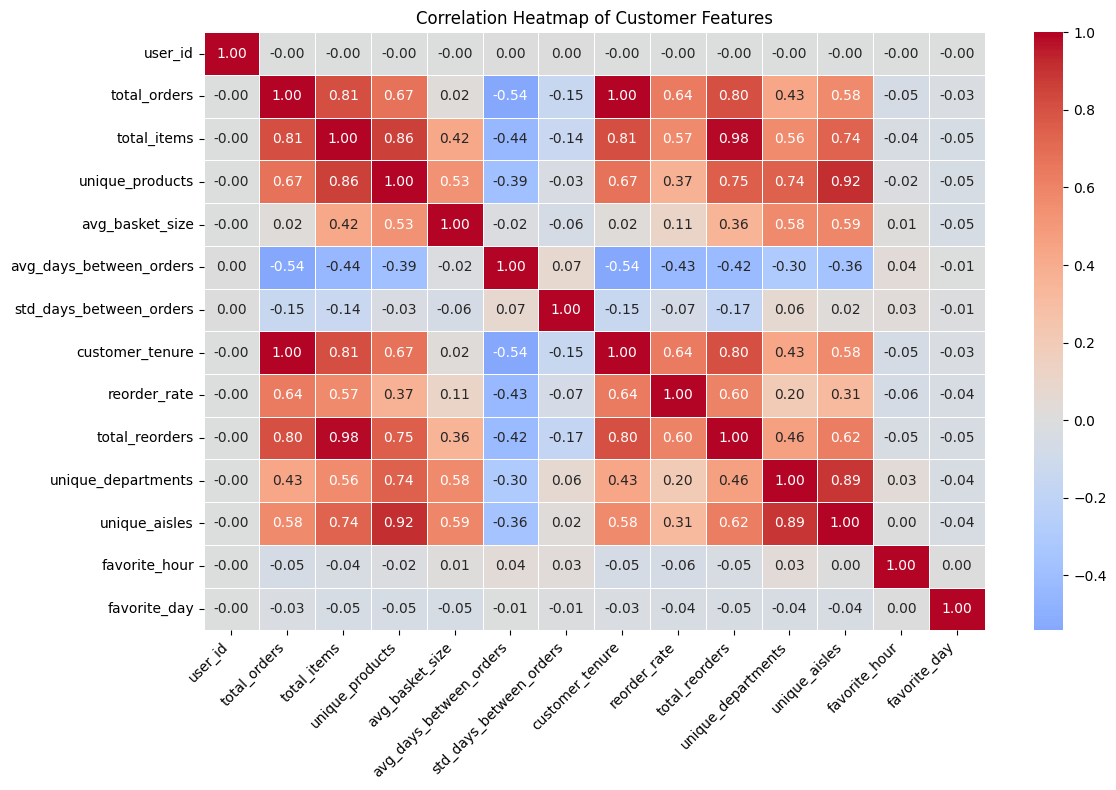

In [27]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    customer_df.corr(),
    annot=True,
    fmt=".2f",        
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Customer Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

## Correlation Analysis of Customer Features

The correlation heatmap provides insights into relationships among customer behavioral features. Correlation coefficients range from -1 to 1, where values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values near 0 indicate little or no linear relationship.

---

## Strong Positive Correlations

### Total Items and Total Reorders (0.98)

The strongest positive correlation observed is between `total_items` and `total_reorders`.

**Interpretation:**
Customers who purchase more products tend to generate more repeat purchases.

**Business Insight:**
This relationship highlights the importance of highly engaged customers, as increased purchasing activity is strongly associated with product loyalty.

---

### Unique Products and Unique Aisles (0.92)

A very strong positive correlation exists between `unique_products` and `unique_aisles`.

**Interpretation:**
Customers purchasing a wider variety of products naturally interact with more aisles.

**Business Insight:**
This feature pair captures customer exploration behavior and category diversity.

---

### Unique Departments and Unique Aisles (0.89)

Customers who purchase across many departments also tend to shop across a larger number of aisles.

**Business Insight:**
Broad category exploration often translates into broader product discovery across the platform.

---

### Total Items and Unique Products (0.86)

Customers purchasing more items generally purchase a wider variety of products.

**Business Insight:**
High-volume shoppers tend to be more diverse in their purchasing behavior.

---

### Total Orders and Total Items (0.81)

Customers placing more orders generally purchase more items overall.

**Business Insight:**
Purchase frequency and purchasing volume are closely connected indicators of customer engagement.

---

### Total Orders and Total Reorders (0.80)

Customers with higher order frequency tend to generate more repeat purchases.

**Business Insight:**
Frequent shoppers often demonstrate stronger loyalty and product familiarity.

---

## Moderate Positive Correlations

### Reorder Rate and Total Orders (0.64)

Customers with more orders tend to exhibit higher reorder rates.

**Interpretation:**
Longer engagement with the platform increases the likelihood of repeat purchasing behavior.

---

### Average Basket Size and Unique Aisles (0.59)

Customers with larger baskets typically purchase products from a broader set of aisles.

**Business Insight:**
Larger shopping missions are associated with greater product category diversity.

---

### Average Basket Size and Unique Departments (0.58)

Customers placing larger orders tend to purchase products from multiple departments.

---

### Total Reorders and Unique Aisles (0.62)

Customers who frequently reorder products often interact with a wider variety of product categories.

---

## Negative Correlations

### Total Orders and Average Days Between Orders (-0.54)

A strong negative relationship exists between purchase frequency and average time between orders.

**Interpretation:**
Customers who order more frequently tend to have shorter intervals between purchases.

**Business Insight:**
This relationship reflects customer engagement and purchasing consistency.

---

### Reorder Rate and Average Days Between Orders (-0.43)

Customers with higher reorder rates tend to place orders more frequently.

**Business Insight:**
Loyal customers typically return to the platform more often.

---

### Total Reorders and Average Days Between Orders (-0.42)

Frequent repeat purchasers generally have shorter gaps between shopping sessions.

---

### Unique Products and Average Days Between Orders (-0.39)

Customers who purchase a wider variety of products tend to shop more frequently.

---

## Weak or No Correlations

### Favorite Hour

The `favorite_hour` feature exhibits very weak correlations with all other customer features.

**Interpretation:**
Preferred shopping time appears largely independent of customer purchasing volume, loyalty, and product diversity.

---

### Favorite Day

Similarly, `favorite_day` shows minimal correlation with other behavioral metrics.

**Interpretation:**
Preferred shopping day captures a distinct behavioral characteristic not explained by purchasing activity.

---

## Feature Engineering Observation

The heatmap reveals a perfect correlation between `customer_tenure` and `total_orders` (correlation = 1.00).

Further investigation confirmed that:

```python
customer_tenure == total_orders
```

for every customer in the dataset.

Therefore, `customer_tenure` does not provide additional information and was removed from the feature store to avoid redundancy and multicollinearity.

---

## Key Findings

### Customer Loyalty Signals

The strongest indicators of loyalty include:

- Reorder Rate
- Total Reorders
- Total Orders

These features are closely interconnected and collectively describe customer retention behavior.

---

### Product Exploration Signals

Features related to customer exploration show strong relationships:

- Unique Products
- Unique Departments
- Unique Aisles

These metrics capture the breadth of customer purchasing behavior across the platform.

---

### Purchase Frequency Signals

Features associated with customer activity frequency include:

- Total Orders
- Average Days Between Orders
- Total Reorders

These metrics help distinguish highly engaged customers from infrequent shoppers.

---

## Conclusion

The correlation analysis reveals three primary dimensions of customer behavior:

1. **Loyalty and Repeat Purchasing**
   - Total Orders
   - Reorder Rate
   - Total Reorders

2. **Product and Category Exploration**
   - Unique Products
   - Unique Departments
   - Unique Aisles

3. **Purchase Frequency**
   - Average Days Between Orders
   - Order Volume Metrics

Overall, the customer feature store captures multiple complementary aspects of customer behavior, providing a strong foundation for customer intelligence, recommendation systems, demand forecasting, and business analytics applications.

In [28]:
(customer_df["customer_tenure"] /
 customer_df["total_orders"]).describe()

count    206209.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
dtype: float64

### Validation of Customer Tenure Feature

To verify the relationship between `customer_tenure` and `total_orders`, the ratio

```python
customer_tenure / total_orders
```

was analyzed.

The resulting statistics were:

| Metric | Value |
|---------|---------|
| Mean | 1.0 |
| Standard Deviation | 0.0 |
| Minimum | 1.0 |
| Maximum | 1.0 |

Since the ratio is exactly equal to 1 for every customer, it confirms that:

```text
customer_tenure = total_orders
```

for all records in the dataset.

This indicates that `customer_tenure` is a duplicate feature and does not provide any additional information beyond `total_orders`.

As a result, the feature was removed from subsequent analyses and feature store design to eliminate redundancy and avoid multicollinearity.

**Decision:** Drop `customer_tenure` and retain `total_orders` as the representative feature for customer purchase frequency.